## 1. Périmètre et Données
* Volume et granularité : 2712 lignes et 21 colonnes et chaque ligne represente une demande de crédit
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_credit                   2712 non-null   str    
 1   nb_transactions_30j         2712 non-null   int64  
 2   nb_transactions_60j         2712 non-null   int64  
 3   nb_transactions_90j         2712 non-null   int64  
 4   nb_jours_actifs_90j         2712 non-null   int64  
 5   volume_entrant_90j          2712 non-null   float64
 6   volume_sortant_90j          2712 non-null   float64
 7   ratio_flux_entrant_sortant  2712 non-null   float64
 8   montant_moyen_90j           2712 non-null   float64
 9   montant_median_90j          2712 non-null   float64
 10  regularite_transactions     2712 non-null   float64
  11  variation_volume_mensuel    2712 non-null   float64
 12  nb_credits_precedents       2712 non-null   int64  
 13  nb_credits_impayes          2712 non-null   int64  
 14  nb_retards                  2712 non-null   int64  
 15  retard_moyen_jours          2712 non-null   float64
 16  taux_remboursement          2712 non-null   float64
 17  montant_credit_demande      2712 non-null   int64  
 18  duree_credit_demande        2712 non-null   int64  
 19  defaut                      2712 non-null   int64  
 20  sans_historique_credit      2712 non-null   int64  
dtypes: float64(9), int64(11), str(1)
memory usage: 445.1 KB

* Cible : Modalités(0 et 1). Sur un total de 2712 , 2282 sains( 0 ) et 430 defaut ( 1 )
* Diagnostic de déséquilibre : Le dataset présente un fort déséquilibre de classe avec environ 84,14 pourcent de 0 contre environ 15,86 pourcent de 1
## 2. Qualité de données : 
* Valeurs manquantes & anomalies : le dataset contenait 1796 valeurs manquantes sur les variables retard_moyen_jours et taux_remboursement sachant qu'il y a des demandes crédits pour des clients qui n'ont jamais fait de crédit j'ai créé une nouvelle variable pour les différencier de ceux qui ont dejà fait des crédit et qui ont remboursé . 
## 3. Les Comportements & Signaux Forts (L'Analyse Univariée & Bivariée):
* Les Variables Discriminantes (Séparation des profils): 
taux_remboursement (Le signal majeur) :C'est la variable la plus fortement discriminante. Pour les clients sains (0), la distribution est concentrée au sommet à 1.0(100% de remboursement). Pour les clients en défaut (1), le troisième quartile ($Q3$) chute à 0.5(50%) et la médiane descend à 0.0, indiquant un effondrement direct du taux de remboursement.
* retard_moyen_jours (Signaux d'alerte extrêmes) :Alors que la majorité des clients sains n'ont quasiment aucun retard (boîte centrée à 0), le groupe en défaut présente de nombreux outliers s'étendant de 20 jusqu'à 120 jours de retard. 
* L'activité globale (nb_transactions_60j, 90j et regularite_transactions) :
Les clients en défaut montrent une légère baisse de leur médiane d'activité et de régularité par rapport aux clients sains.
* Variables neutres (Non discriminantes) :
Le montant du crédit demandé (montant_credit_demande) et sa durée (duree_credit_demande) présentent des distributions strictement identiques entre les deux groupes. Elles n'ont aucun pouvoir séparateur direct.
## 2. Les Corrélations Marquantes (Relations entre variables) : 
D'après la structure de corrélation analysée :
* Mise en évidence du triptyque de risque :Il existe une très forte corrélation négative (r = -0.942) entre le nombre d'impayés (nb_credits_impayes) / le retard moyen (retard_moyen_jours) et le taux de remboursement (taux_remboursement).
* Explication mécanique : Chaque incident de paiement enregistré (nb_credits_impayes >= 1) s'accompagne immédiatement d'une hausse mécanique du retard moyen, ce qui détruit directement le ratio de remboursement du client.
* Forte multicolinéarité sur l'activité transactionnelle : 
Les variables de fréquence de transaction (nb_transactions_30j, 60j, 90j) et de jours actifs (nb_jours_actifs_90j) sont quasi parfaitement corrélées entre elles (r >= 0.70 et approchant 1.00).
## Alerte pour le Data Scientist : 
Elles apportent la même information redondante. Il faudra en sélectionner une seule ou appliquer une méthode de réduction de dimension.

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
#Importation du fichier
import pandas as pd
import numpy as np 
df=pd.read_csv("../data/processed/dataset_credit.csv")
df.head()

,id_credit,nb_transactions_30j,nb_transactions_60j,nb_transactions_90j,nb_jours_actifs_90j,volume_entrant_90j,volume_sortant_90j,ratio_flux_entrant_sortant,montant_moyen_90j,montant_median_90j,regularite_transactions,variation_volume_mensuel,nb_credits_precedents,nb_credits_impayes,nb_retards,retard_moyen_jours,taux_remboursement,montant_credit_demande,duree_credit_demande,defaut
0,cred_002026,8,13,22,19,122738.0,136689.0,0.897936,11792.136364,6776.0,0.211111,-0.448439,0,0,0,NaN,NaN,100000,3,0
1,cred_002225,6,10,13,13,39424.0,17171.0,2.295964,4353.461538,4152.0,0.144444,0.126577,0,0,0,NaN,NaN,5000,3,0
2,cred_001582,6,11,21,21,43873.0,77845.0,0.563594,5796.095238,4109.0,0.233333,-0.472710,0,0,0,NaN,NaN,25000,6,1
3,cred_002437,5,14,19,18,49221.0,71995.0,0.683672,6379.789474,6067.0,0.200000,-0.248396,0,0,0,NaN,NaN,15000,3,0
4,cred_001682,10,16,25,21,63284.0,67362.0,0.939461,5225.840000,4348.0,0.233333,0.158132,0,0,0,NaN,NaN,50000,6,0


In [17]:
df.head(100)

,id_credit,nb_transactions_30j,nb_transactions_60j,nb_transactions_90j,nb_jours_actifs_90j,volume_entrant_90j,volume_sortant_90j,ratio_flux_entrant_sortant,montant_moyen_90j,montant_median_90j,...,variation_volume_mensuel,nb_credits_precedents,nb_credits_impayes,nb_retards,retard_moyen_jours,taux_remboursement,montant_credit_demande,duree_credit_demande,defaut,sans_historique_credit
0,cred_002026,8,13,22,19,122738.0,136689.0,0.897936,11792.136364,6776.0,...,-0.448439,0,0,0,0.0,0.0,100000,3,0,1
1,cred_002225,6,10,13,13,39424.0,17171.0,2.295964,4353.461538,4152.0,...,0.126577,0,0,0,0.0,0.0,5000,3,0,1
2,cred_001582,6,11,21,21,43873.0,77845.0,0.563594,5796.095238,4109.0,...,-0.472710,0,0,0,0.0,0.0,25000,6,1,1
3,cred_002437,5,14,19,18,49221.0,71995.0,0.683672,6379.789474,6067.0,...,-0.248396,0,0,0,0.0,0.0,15000,3,0,1
4,cred_001682,10,16,25,21,63284.0,67362.0,0.939461,5225.840000,4348.0,...,0.158132,0,0,0,0.0,0.0,50000,6,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,cred_001549,5,13,19,19,53421.0,84593.0,0.631506,7263.894737,6808.0,...,0.055354,0,0,0,0.0,0.0,15000,9,0,1
96,cred_000010,4,12,15,14,55688.0,87939.0,0.633257,9575.133333,4133.0,...,-0.626970,0,0,0,0.0,0.0,5000,6,0,1
97,cred_002699,7,11,16,16,19841.0,81205.0,0.244332,6315.375000,2398.0,...,-0.016944,0,0,0,0.0,0.0,25000,6,1,1
98,cred_002432,6,11,16,16,27214.0,50472.0,0.539190,4855.375000,5154.5,...,0.133260,0,0,0,0.0,0.0,10000,6,0,1


In [18]:
print(df["taux_remboursement"].unique())

[0.  1.  0.5]


In [2]:
#Nombre de lignes et de colonnes du dataset
df.shape

(2712, 20)

In [3]:
#Valeurs manquantes
df.isnull().sum()


id_credit                        0
nb_transactions_30j              0
nb_transactions_60j              0
nb_transactions_90j              0
nb_jours_actifs_90j              0
volume_entrant_90j               0
volume_sortant_90j               0
ratio_flux_entrant_sortant       0
montant_moyen_90j                0
montant_median_90j               0
regularite_transactions          0
variation_volume_mensuel         0
nb_credits_precedents            0
nb_credits_impayes               0
nb_retards                       0
retard_moyen_jours            1796
taux_remboursement            1796
montant_credit_demande           0
duree_credit_demande             0
defaut                           0
dtype: int64

In [4]:
# Liste des catégories uniques
print(df["retard_moyen_jours"].unique())

[  nan   1.    0.   77.   84.    5.   10.   51.  108.   85.   61.   64.
  80.   37.   67.   35.   55.   43.5  27.5  81.   73.   95.    2.5  58.
 113.   45.  101.   34.5  88.   31.   33.   96.   59.5   2.   15.   99.
 116.   69.  102.   63.   29.  114.  106.   56.5  57.    0.5  46.   50.5
  22.   22.5   7.5  39.   34.  100.   65.   18.5  60.   97.   94.   31.5
  72.  104.   98.  117.   50.    3.5  70.   42.   32.   93.   48.   49.
  66.   54.  119.   83.   47.5  20.5  71.   71.5 109.   24.   36.   41.5
  87.   30.5  82.   40.    3.   16.   15.5  43.  103.   92.   89.   40.5
 107.   45.5  41.   44.   35.5  60.5 111.   49.5 112.   17.   86.   33.5
  21.   74.   38.    5.5  16.5  46.5]


In [5]:
# Étape 1 : Créer une colonne indicateur (1 = Nouveau client sans historique, 0 = Ancien client)
df["sans_historique_credit"] = df["retard_moyen_jours"].isna().astype(int)

# Étape 2 : Remplacer les NaN par 0
df["retard_moyen_jours"] = df["retard_moyen_jours"].fillna(0)
df["taux_remboursement"] = df["taux_remboursement"].fillna(0)

# Étape 3 : Vérifier qu'il n'y a plus aucun trou
print(df[["retard_moyen_jours", "taux_remboursement"]].isnull().sum())

retard_moyen_jours    0
taux_remboursement    0
dtype: int64


In [6]:
#Valeurs manquantes
df.isnull().sum()

id_credit                     0
nb_transactions_30j           0
nb_transactions_60j           0
nb_transactions_90j           0
nb_jours_actifs_90j           0
volume_entrant_90j            0
volume_sortant_90j            0
ratio_flux_entrant_sortant    0
montant_moyen_90j             0
montant_median_90j            0
regularite_transactions       0
variation_volume_mensuel      0
nb_credits_precedents         0
nb_credits_impayes            0
nb_retards                    0
retard_moyen_jours            0
taux_remboursement            0
montant_credit_demande        0
duree_credit_demande          0
defaut                        0
sans_historique_credit        0
dtype: int64

In [7]:
# Compter le nombre de lignes doublons
nb_doublons = df.duplicated().sum()
print(f"Nombre de doublons stricts : {nb_doublons}")

Nombre de doublons stricts : 0


In [8]:
#Verification des types de variables 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2712 entries, 0 to 2711
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_credit                   2712 non-null   str    
 1   nb_transactions_30j         2712 non-null   int64  
 2   nb_transactions_60j         2712 non-null   int64  
 3   nb_transactions_90j         2712 non-null   int64  
 4   nb_jours_actifs_90j         2712 non-null   int64  
 5   volume_entrant_90j          2712 non-null   float64
 6   volume_sortant_90j          2712 non-null   float64
 7   ratio_flux_entrant_sortant  2712 non-null   float64
 8   montant_moyen_90j           2712 non-null   float64
 9   montant_median_90j          2712 non-null   float64
 10  regularite_transactions     2712 non-null   float64
 11  variation_volume_mensuel    2712 non-null   float64
 12  nb_credits_precedents       2712 non-null   int64  
 13  nb_credits_impayes          2712 non-null   

In [9]:
#Verification des valeurs aberrantes
df.describe()

,nb_transactions_30j,nb_transactions_60j,nb_transactions_90j,nb_jours_actifs_90j,volume_entrant_90j,volume_sortant_90j,ratio_flux_entrant_sortant,montant_moyen_90j,montant_median_90j,regularite_transactions,variation_volume_mensuel,nb_credits_precedents,nb_credits_impayes,nb_retards,retard_moyen_jours,taux_remboursement,montant_credit_demande,duree_credit_demande,defaut,sans_historique_credit
count,2712.000000,2712.000000,2712.000000,2712.000000,2.712000e+03,2.712000e+03,2712.000000,2712.000000,2712.000000,2712.000000,2712.000000,2712.000000,2712.000000,2712.000000,2712.000000,2712.000000,2712.000000,2712.000000,2712.000000,2712.000000
mean,6.183997,12.342920,18.568953,16.747419,7.523195e+04,9.720992e+04,1.357434,9281.144369,4318.179388,0.186082,0.002150,0.418142,0.069690,0.155236,4.563606,0.281895,20663.716814,6.227876,0.158555,0.662242
std,2.546881,3.665117,4.433829,3.787805,9.991506e+04,1.085359e+05,2.423776,7639.574145,1228.457358,0.042087,0.468069,0.635779,0.264616,0.388722,17.483230,0.443711,23109.488006,2.835797,0.365328,0.473033
min,0.000000,3.000000,7.000000,6.000000,1.025000e+03,4.536000e+03,0.012265,2181.636364,1495.000000,0.066667,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5000.000000,3.000000,0.000000,0.000000
25%,4.000000,10.000000,15.000000,14.000000,3.204900e+04,4.580175e+04,0.371738,5400.076667,3457.500000,0.155556,-0.342006,0.000000,0.000000,0.000000,0.000000,0.000000,5000.000000,3.000000,0.000000,0.000000
50%,6.000000,12.000000,18.000000,17.000000,4.913550e+04,6.781350e+04,0.709018,6846.759259,4137.250000,0.188889,-0.000666,0.000000,0.000000,0.000000,0.000000,0.000000,10000.000000,6.000000,0.000000,1.000000
75%,8.000000,15.000000,21.000000,19.000000,7.603150e+04,1.040538e+05,1.389250,9858.972744,4972.750000,0.211111,0.361297,1.000000,0.000000,0.000000,0.000000,1.000000,25000.000000,9.000000,0.000000,1.000000
max,19.000000,25.000000,36.000000,31.000000,1.628654e+06,2.356831e+06,40.620238,103867.000000,12422.000000,0.344444,1.000000,2.000000,2.000000,2.000000,119.000000,1.000000,100000.000000,12.000000,1.000000,1.000000


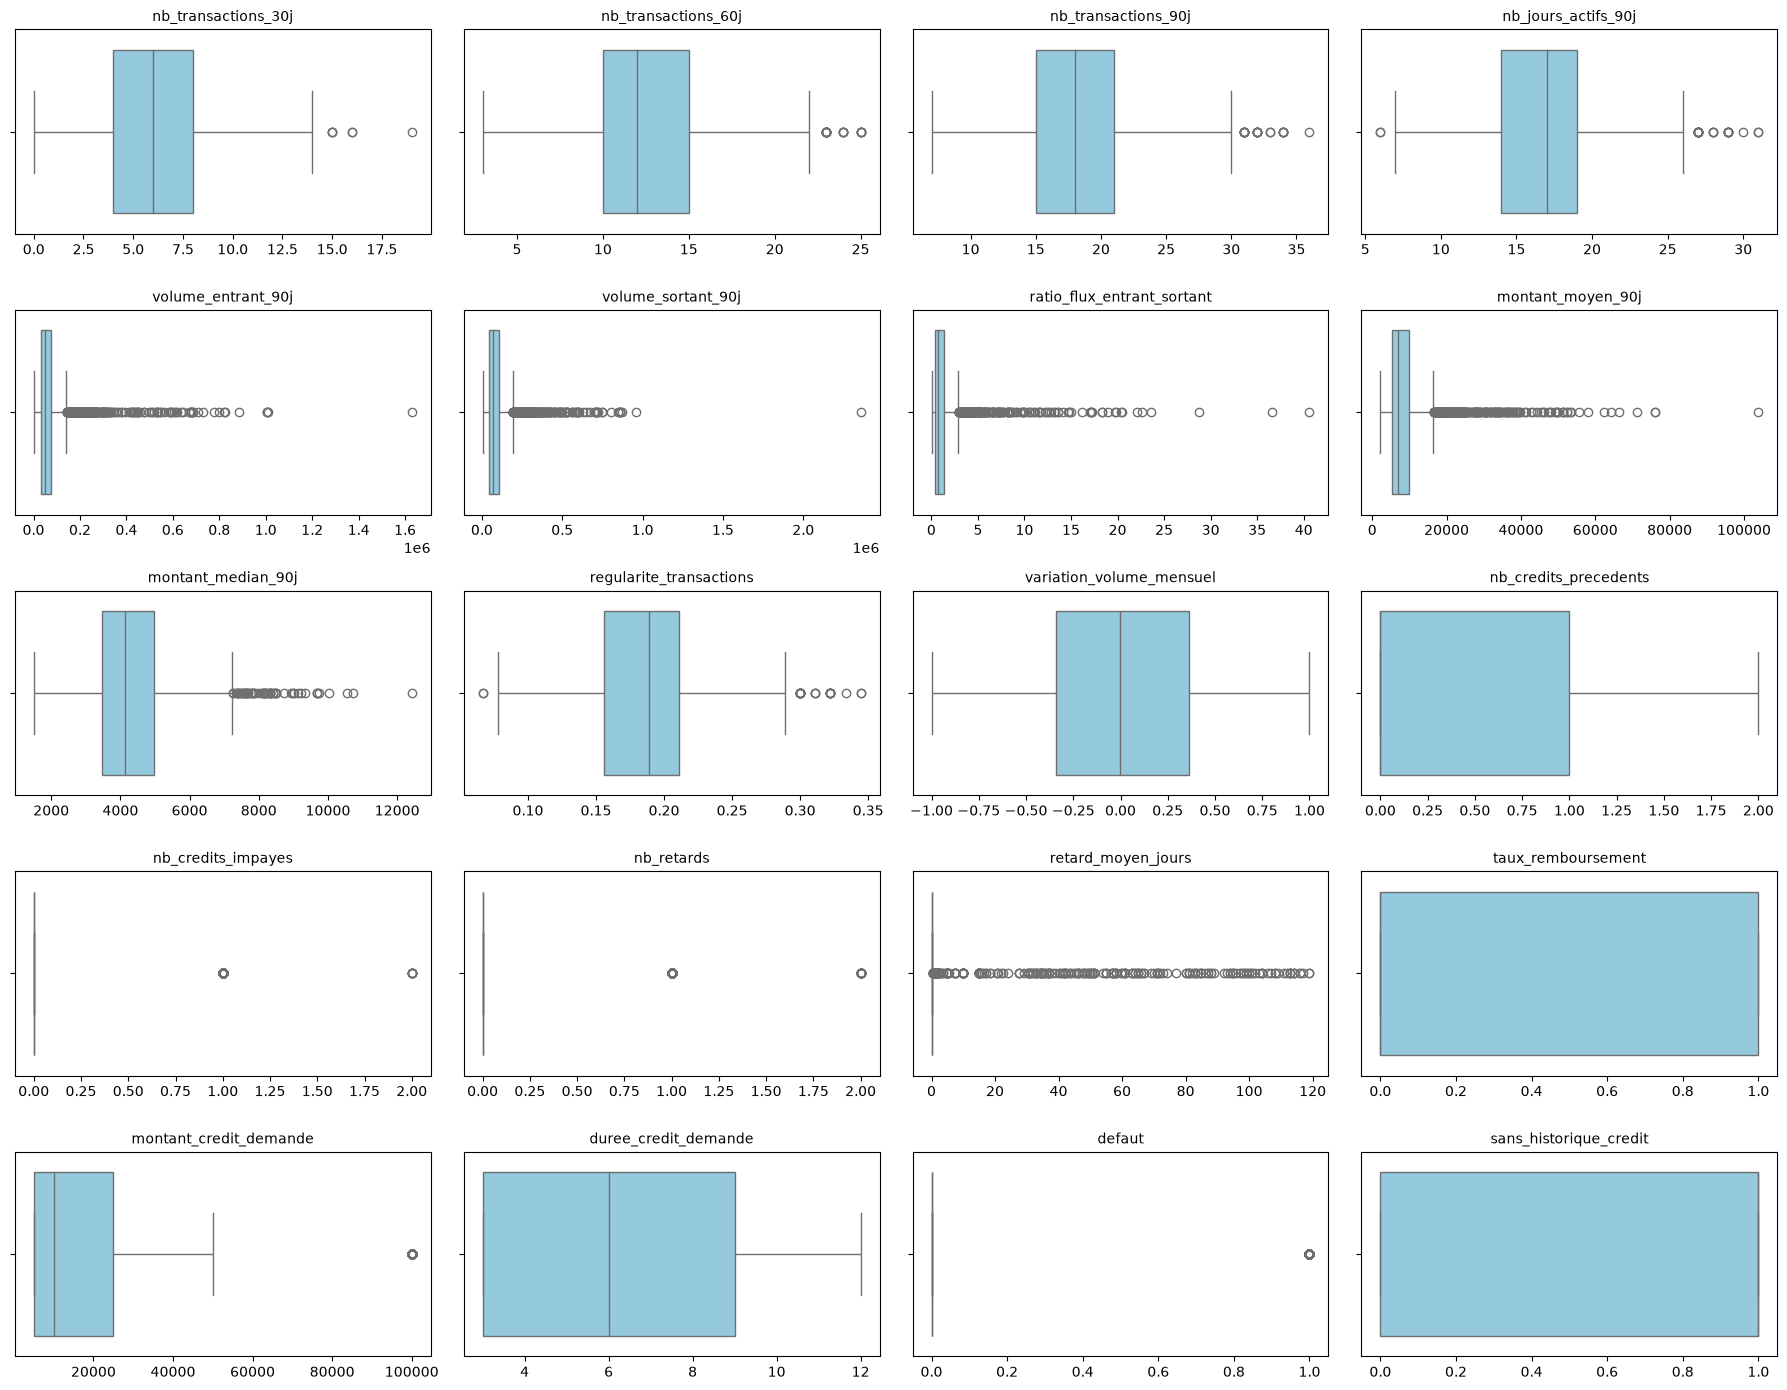

In [10]:
# Verification des valeurs aberrantes
# 1. Sélection de toutes les colonnes numériques
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# 2. Création d'une grille de graphiques (ex: 5 lignes x 4 colonnes = 20 variables)
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(18, 14))
axes = axes.flatten()  # Applatir la grille pour boucler facilement dessus

# 3. Boucle pour afficher chaque boxplot
for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

# Masquer les sous-graphiques vides s'il y a moins de 20 variables
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

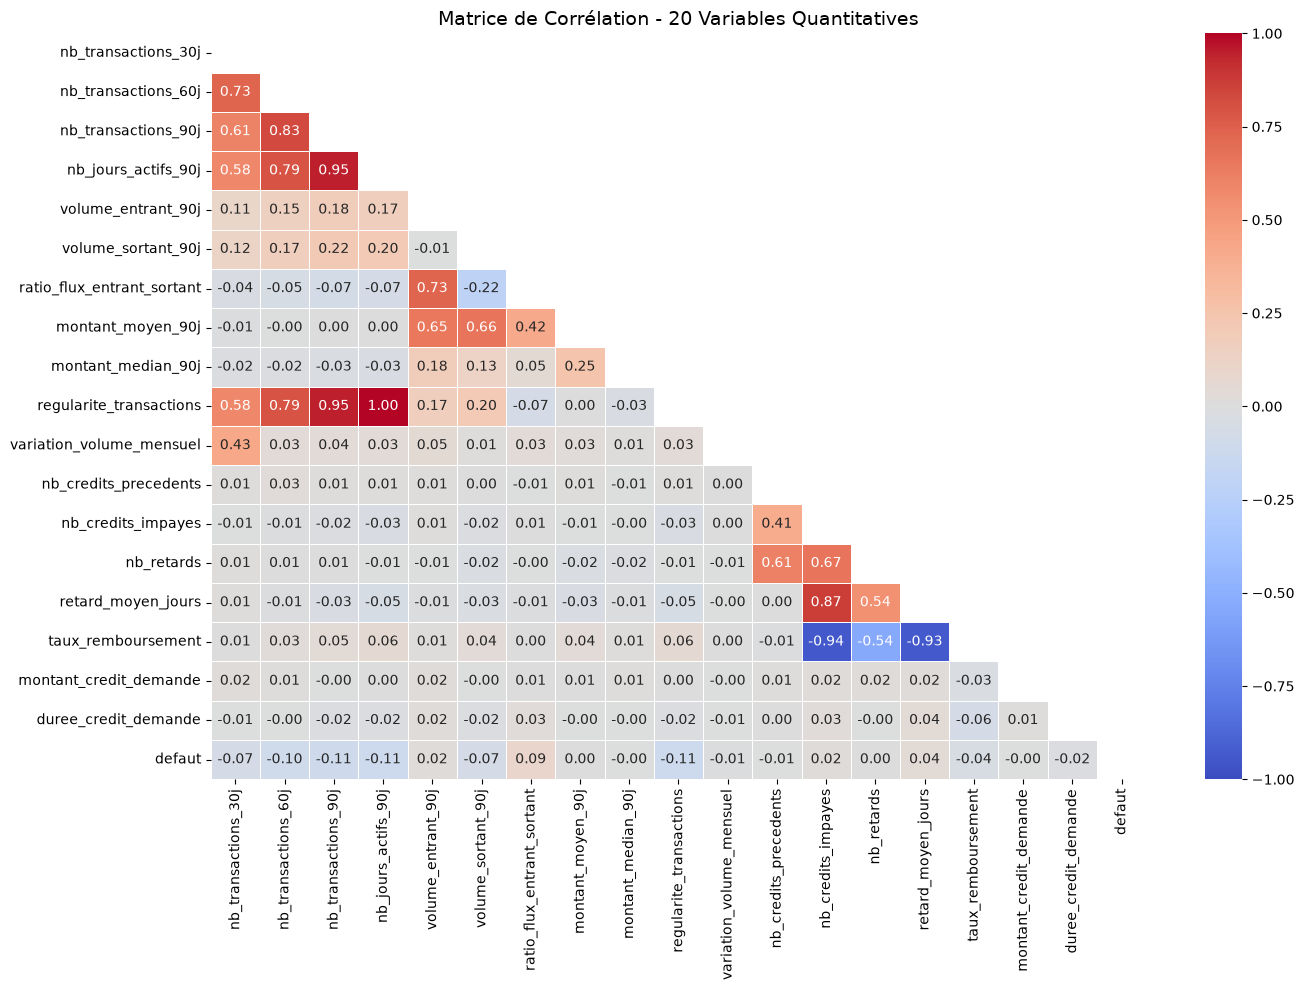

--- Paires de variables fortement corrélées (|r| >= 0.70) ---
              Variable 1                  Variable 2  Correlation
66   nb_jours_actifs_90j     regularite_transactions     1.000000
47   nb_transactions_90j     regularite_transactions     0.949547
41   nb_transactions_90j         nb_jours_actifs_90j     0.949547
242   nb_credits_impayes          retard_moyen_jours     0.872963
21   nb_transactions_60j         nb_transactions_90j     0.829640
28   nb_transactions_60j     regularite_transactions     0.791949
22   nb_transactions_60j         nb_jours_actifs_90j     0.791949
82    volume_entrant_90j  ratio_flux_entrant_sortant     0.728190
1    nb_transactions_30j         nb_transactions_60j     0.727566
281   retard_moyen_jours          taux_remboursement    -0.931104
243   nb_credits_impayes          taux_remboursement    -0.942239


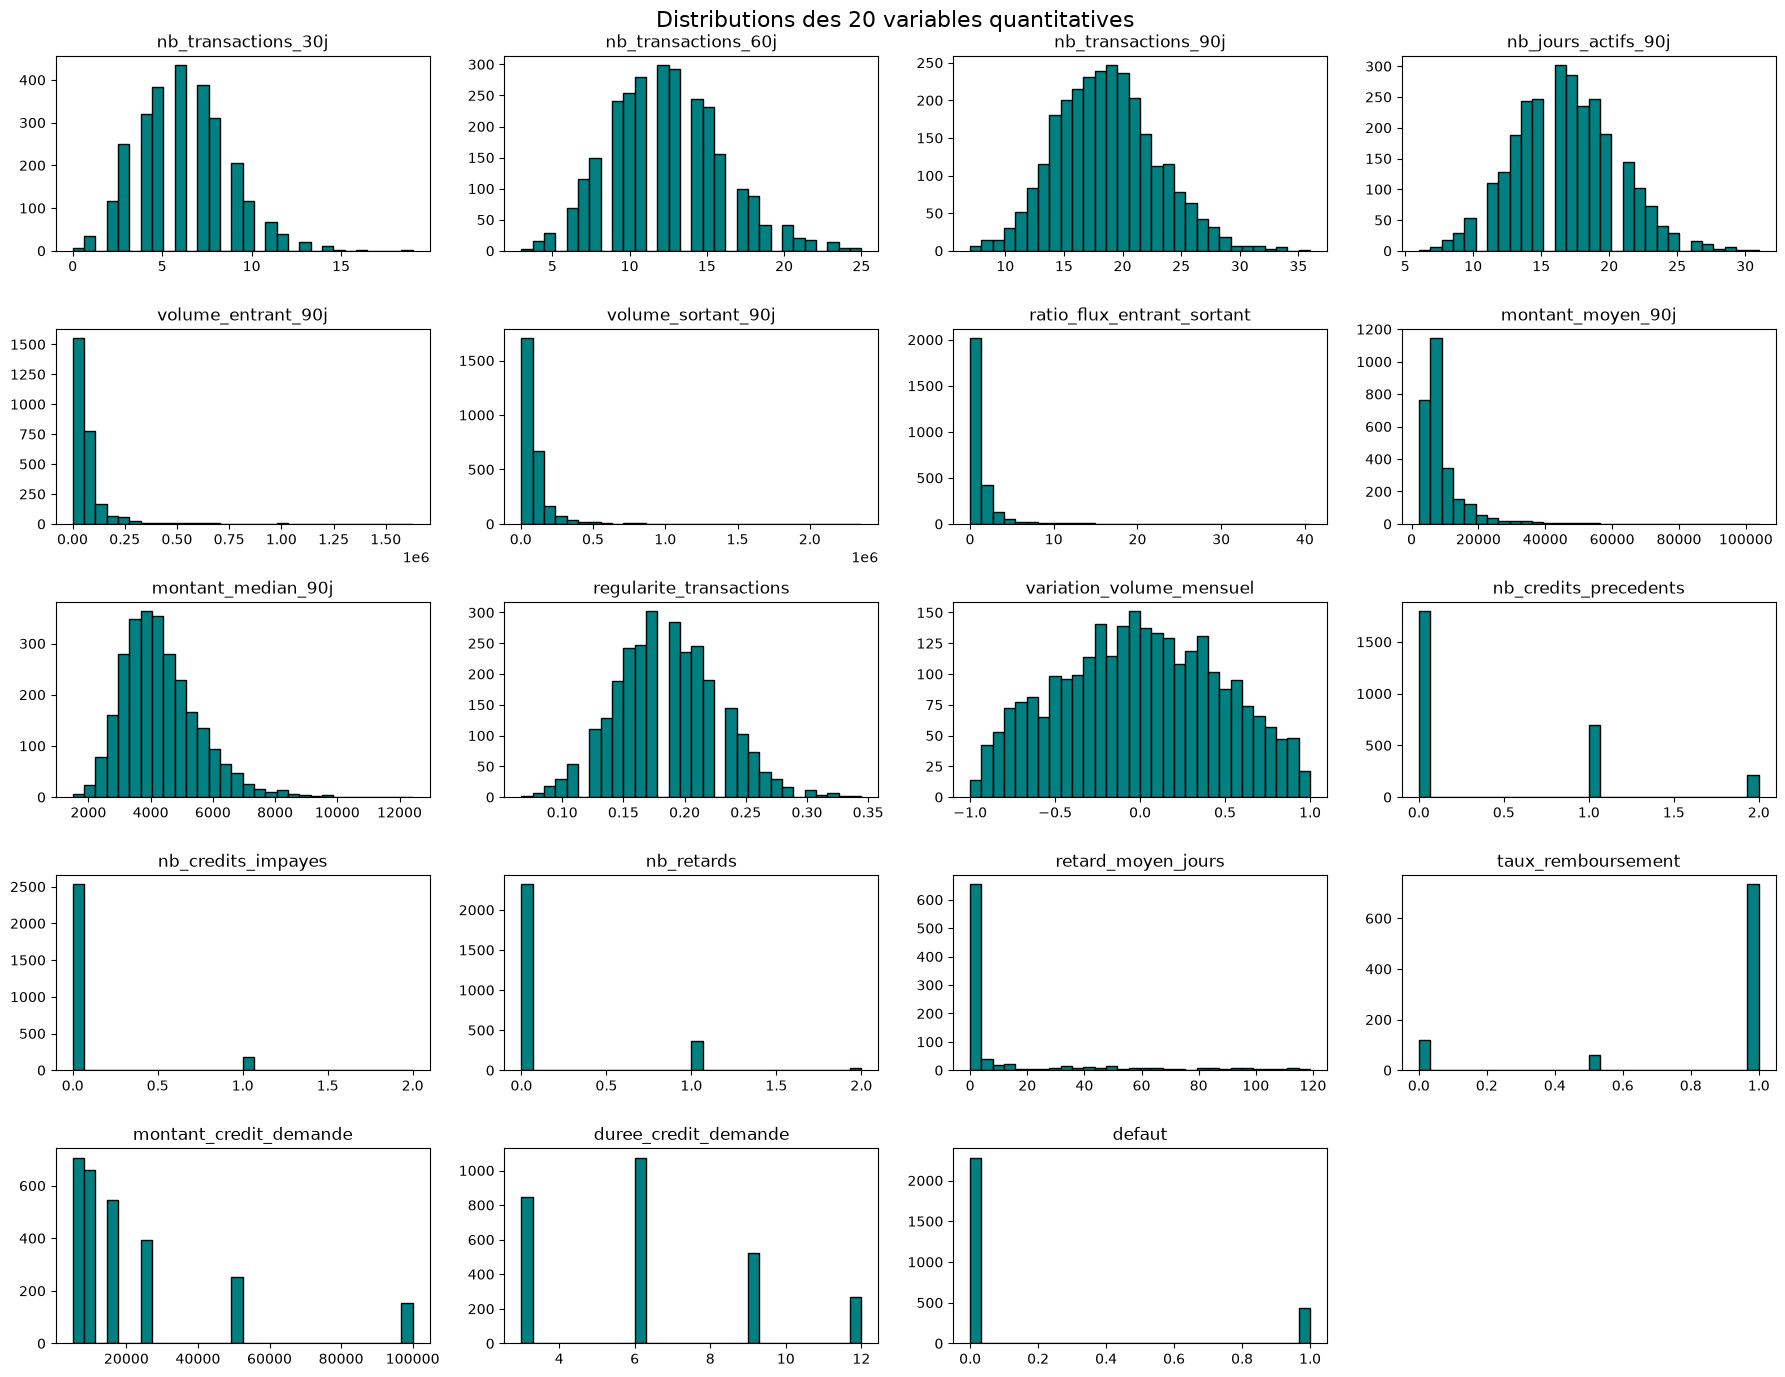

In [22]:

# ---------------------------------------------------------
# A. Matrice de Corrélation globale
# ---------------------------------------------------------
plt.figure(figsize=(14, 10))
corr_matrix = df.corr(numeric_only=True)

#Masque pour cacher la moitié supérieure symétrique (plus lisible)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, vmax=1, 
    linewidths=0.5
)
plt.title("Matrice de Corrélation - 20 Variables Quantitatives", fontsize=14)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# B. Détection automatique des fortes colinéarités (|r| >= 0.70)
# ---------------------------------------------------------
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
strong_corr = upper_tri.stack().reset_index()
strong_corr.columns = ['Variable 1', 'Variable 2', 'Correlation']
strong_corr = strong_corr[strong_corr['Correlation'].abs() >= 0.70].sort_values(by='Correlation', ascending=False)

print("--- Paires de variables fortement corrélées (|r| >= 0.70) ---")
print(strong_corr)

# ---------------------------------------------------------
# C. Distribution de toutes les variables (Histogames + KDE)
# ---------------------------------------------------------
df.hist(figsize=(18, 14), bins=30, color='teal', edgecolor='black', grid=False)
plt.suptitle("Distributions des 20 variables quantitatives", fontsize=16)
plt.tight_layout()
plt.show()

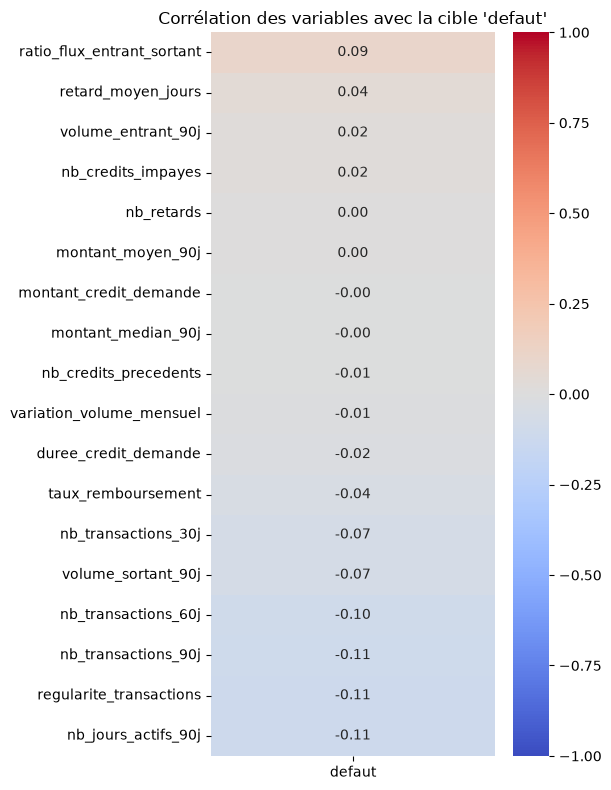

In [ ]:
plt.figure(figsize=(6, 8))

# Extraction uniquement de la corrélation avec 'defaut'
corr_defaut = corr_matrix[['defaut']].drop('defaut').sort_values(by='defaut', ascending=False)

# Affichage en heatmap verticale
sns.heatmap(corr_defaut, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Corrélation des variables avec la cible 'defaut'")
plt.tight_layout()
plt.show()

In [12]:
# 2. Proportions en pourcentage (%)
print("\n--- Proportions (%) ---")
print(df["defaut"].value_counts(normalize=True) * 100)


--- Proportions (%) ---
defaut
0    84.144543
1    15.855457
Name: proportion, dtype: float64


In [14]:
# 1. Effectifs bruts (nombre de lignes)
print("--- Effectifs bruts ---")
print(df["defaut"].value_counts())

--- Effectifs bruts ---
defaut
0    2282
1     430
Name: count, dtype: int64


/tmp/ipykernel_6969/808170310.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_6969/808170310.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_6969/808170310.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_6969/808170310.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_6969/808170310.py:37: FutureWarning: 

Passin

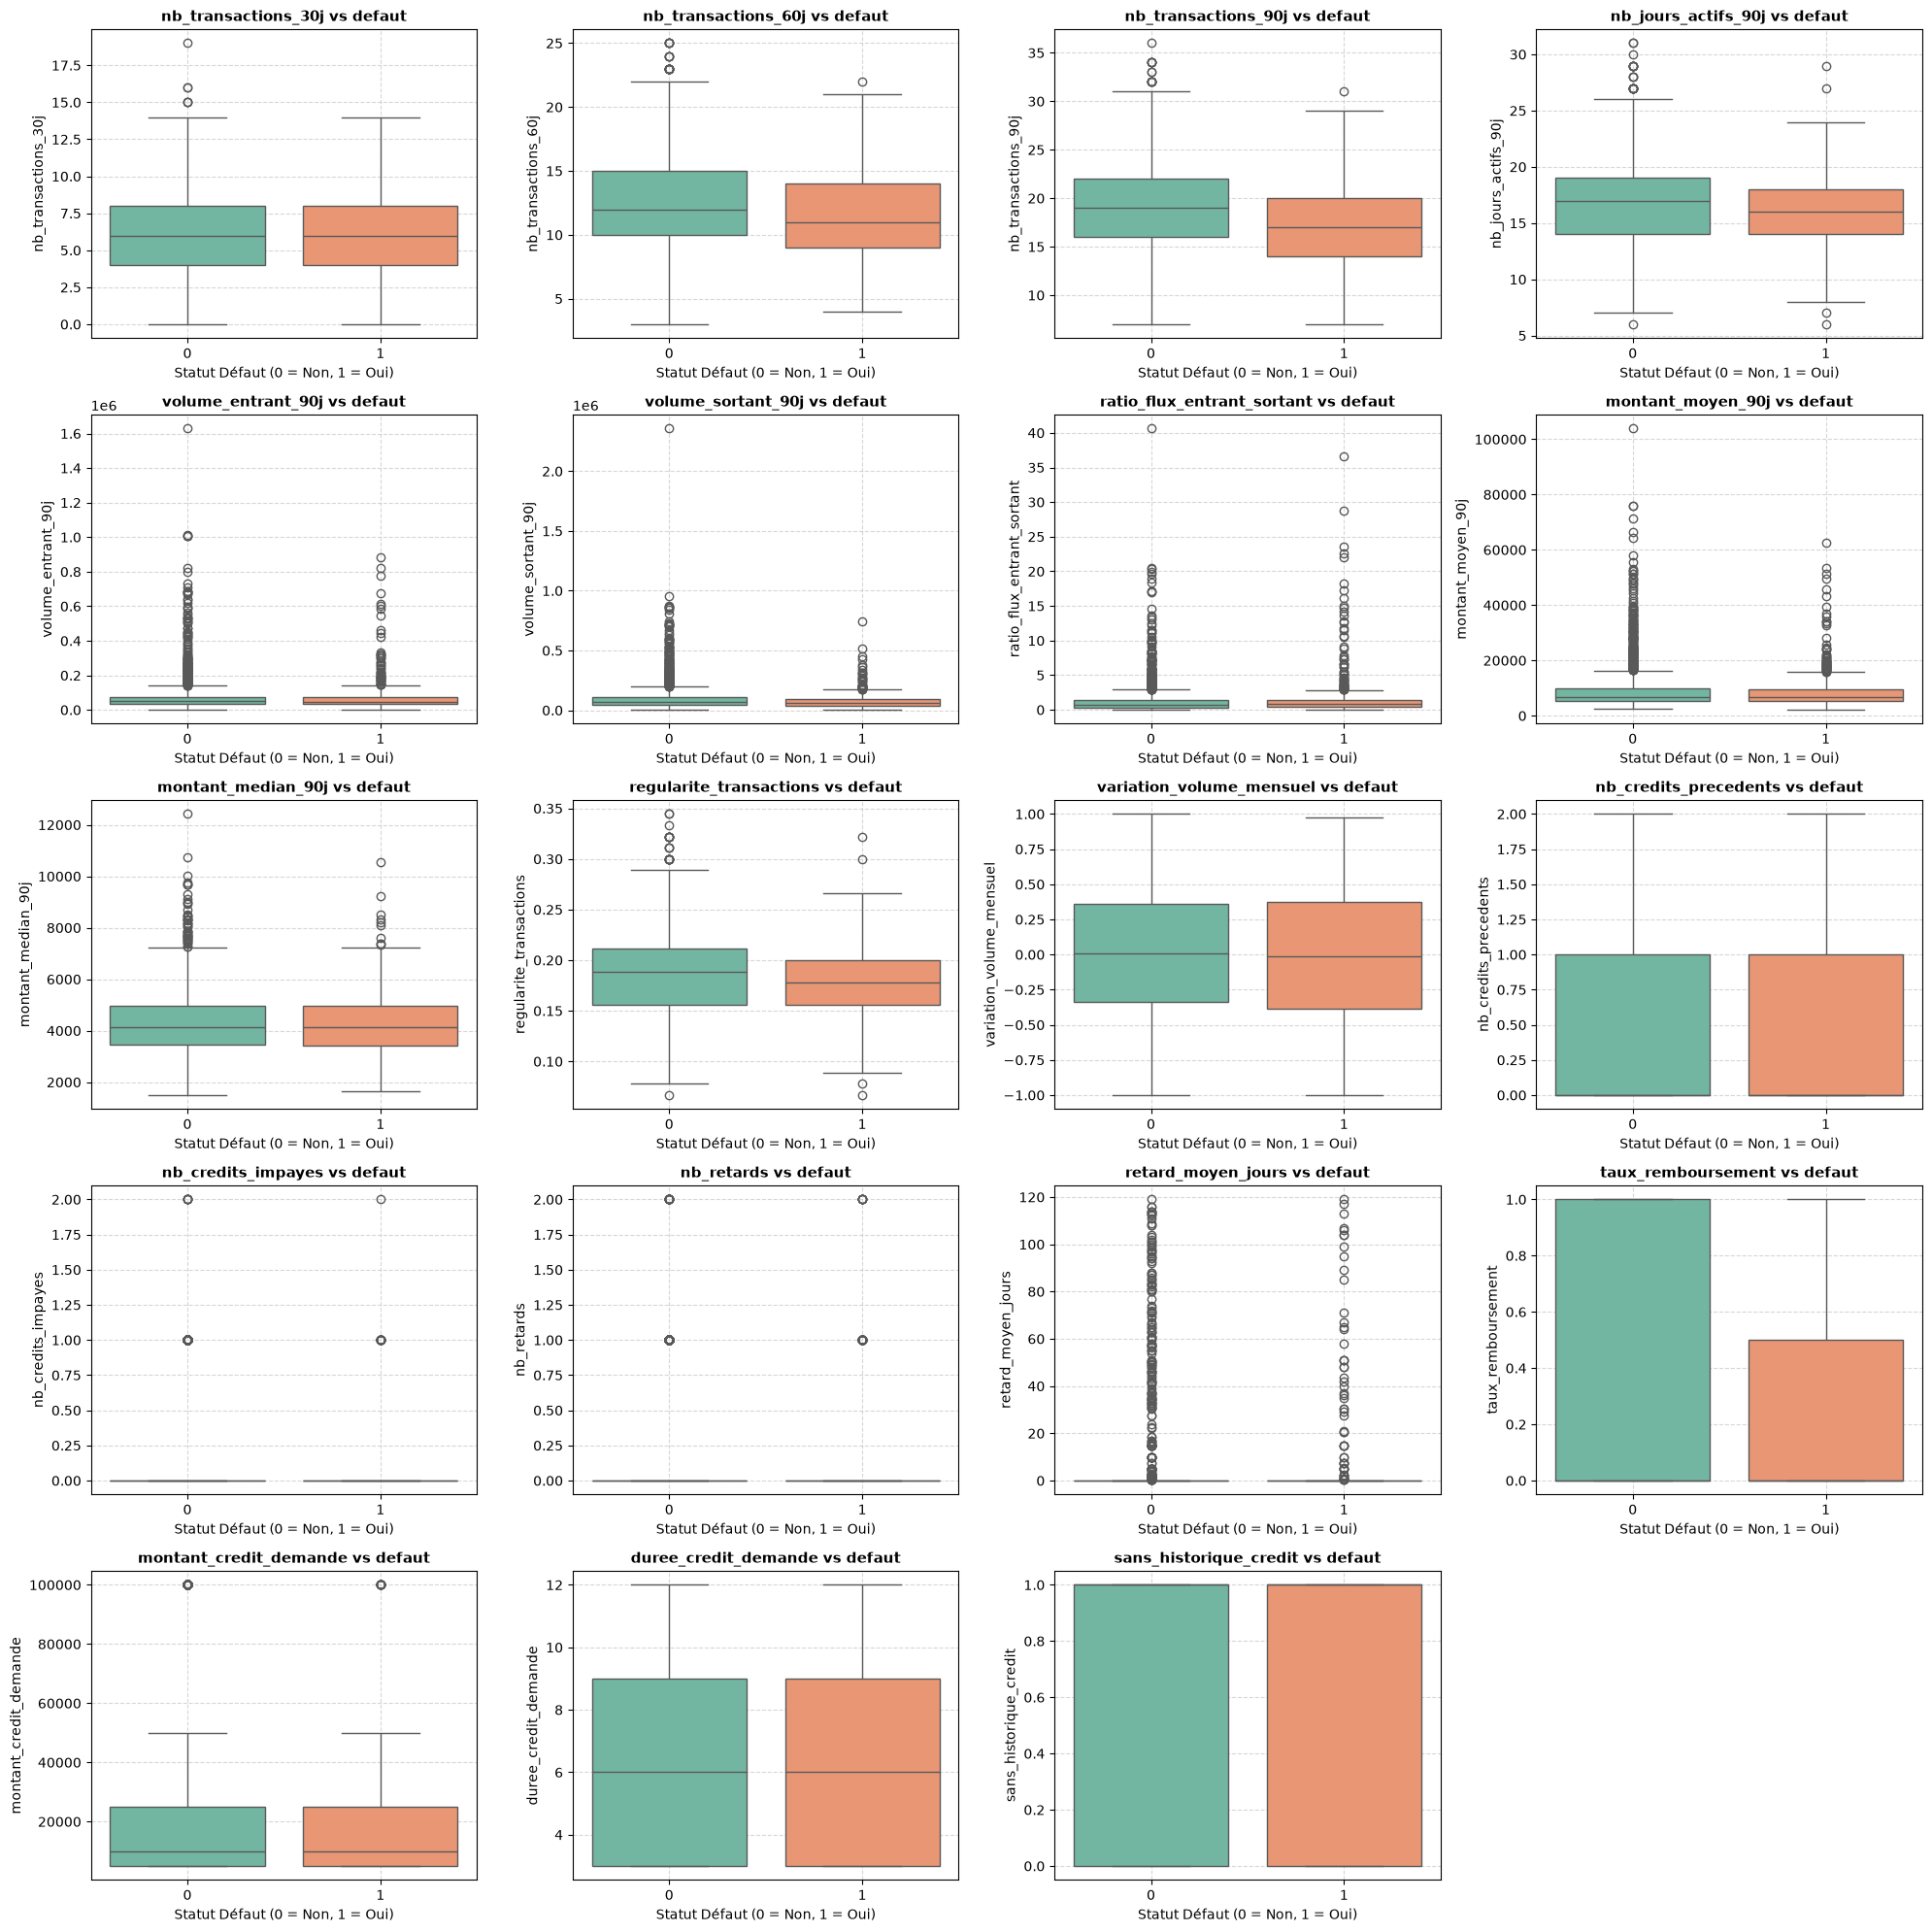

In [15]:
import math

# 1. Liste de toutes vos variables numériques (excluant 'defaut')
variables_num = [
    'nb_transactions_30j',
    'nb_transactions_60j',
    'nb_transactions_90j',
    'nb_jours_actifs_90j',
    'volume_entrant_90j',
    'volume_sortant_90j',
    'ratio_flux_entrant_sortant',
    'montant_moyen_90j',
    'montant_median_90j',
    'regularite_transactions',
    'variation_volume_mensuel',
    'nb_credits_precedents',
    'nb_credits_impayes',
    'nb_retards',
    'retard_moyen_jours',
    'taux_remboursement',
    'montant_credit_demande',
    'duree_credit_demande',
    'sans_historique_credit',
]

# 2. Configuration de la grille de graphiques (ex: 5 lignes x 4 colonnes)
n_vars = len(variables_num)
n_cols = 4
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()  # Aplatir la grille pour faciliter la boucle

# 3. Génération des Boxplots comparatifs par variable
for i, col in enumerate(variables_num):
    if col in df.columns:
        sns.boxplot(
            data=df,
            x='defaut',
            y=col,
            ax=axes[i],
            palette='Set2',
            showfliers=True,  # Met à False si tu veux cacher les outliers extrêmes
        )
        axes[i].set_title(f'{col} vs defaut', fontsize=11, fontweight='bold')
        axes[i].set_xlabel('Statut Défaut (0 = Non, 1 = Oui)')
        axes[i].set_ylabel(col)
        axes[i].grid(True, linestyle='--', alpha=0.5)

# 4. Supprimer les axes inutilisés dans la grille
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [16]:
# Affiche la médiane exacte du taux de remboursement pour chaque groupe
df.groupby('defaut')['taux_remboursement'].median()

defaut
0    0.0
1    0.0
Name: taux_remboursement, dtype: float64

In [19]:
print(df["taux_remboursement"].unique())

[0.  1.  0.5]


In [20]:
#Valeurs manquantes
df.isnull().sum()

id_credit                     0
nb_transactions_30j           0
nb_transactions_60j           0
nb_transactions_90j           0
nb_jours_actifs_90j           0
volume_entrant_90j            0
volume_sortant_90j            0
ratio_flux_entrant_sortant    0
montant_moyen_90j             0
montant_median_90j            0
regularite_transactions       0
variation_volume_mensuel      0
nb_credits_precedents         0
nb_credits_impayes            0
nb_retards                    0
retard_moyen_jours            0
taux_remboursement            0
montant_credit_demande        0
duree_credit_demande          0
defaut                        0
sans_historique_credit        0
dtype: int64